# Builds on Signal Construction and produces long/short/do-nothing signal for past 24 months

##### Step 1: Set datetimes for each month for last 2 years
##### Step 2: Run signal construction code for each month
##### Step 3: Make signal matrix with monthly buy and sell signals

# 1. Get array of Datetime objects for the last 2 years on a monthly frequency

In [1]:
# Our usual imports 
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd

# Define the universe of stocks

univ = ['DUOL', 'PEP', 'KO', 'JNJ', 'IBM', 'MCD', 'WMT', 'PG', 'DIS', 'VZ', 'TMUS', 'COST', 'NKE', 'UPS', 'AVGO', 'TXN', 
        'BAC', 'CAT', 'ORCL', 'HOOD', 'COIN', 'TER', 'PYPL', 'ADBE', 'CRM', 'INTU', 'NFLX', 'AMZN', 'GOOGL', 'META', 'AAPL', 'INTC']

In [2]:
# Make datetime arrays consisting of monthly dates for the last 2 years
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=365*2)
dates = pd.date_range(start=start_date, end=end_date, freq='ME')
dates

DatetimeIndex(['2024-03-31 17:23:31.954462', '2024-04-30 17:23:31.954462',
               '2024-05-31 17:23:31.954462', '2024-06-30 17:23:31.954462',
               '2024-07-31 17:23:31.954462', '2024-08-31 17:23:31.954462',
               '2024-09-30 17:23:31.954462', '2024-10-31 17:23:31.954462',
               '2024-11-30 17:23:31.954462', '2024-12-31 17:23:31.954462',
               '2025-01-31 17:23:31.954462', '2025-02-28 17:23:31.954462',
               '2025-03-31 17:23:31.954462', '2025-04-30 17:23:31.954462',
               '2025-05-31 17:23:31.954462', '2025-06-30 17:23:31.954462',
               '2025-07-31 17:23:31.954462', '2025-08-31 17:23:31.954462',
               '2025-09-30 17:23:31.954462', '2025-10-31 17:23:31.954462',
               '2025-11-30 17:23:31.954462', '2025-12-31 17:23:31.954462',
               '2026-01-31 17:23:31.954462', '2026-02-28 17:23:31.954462',
               '2026-03-31 17:23:31.954462'],
              dtype='datetime64[ns]', freq='ME')

# 2. Importing signal construction code with few tweaks to produce signals for each month for last 2 years

In [3]:
# defining our functions that we are going to use in our loop 

def get_momentum_scores(prices, lookback=252, skip=21):
    """12-month momentum excluding the most recent month."""

    if len(prices) < lookback + skip:
        return {}

    momentum_window = prices.iloc[-(lookback + skip):-skip]

    first = momentum_window.iloc[0]
    last = momentum_window.iloc[-1]

    momentum_scores = (last - first) / first # for now, this is how I calculate momentum score, I will change when I learn more

    return momentum_scores.dropna().to_dict()


def get_reversal_scores(prices, window):
    """Mean-reversion (reverse momentum) over a given window (in trading days)."""

    if len(prices) < window:
        return {}

    reversal_window = prices.iloc[-window:]

    first = reversal_window.iloc[0]
    last = reversal_window.iloc[-1]

    reversal_scores = -((last - first) / first)

    return reversal_scores.dropna().to_dict()


# 
# def get_earnings_scores(tickers):
#    earnings_scores = {}
#    
#    for ticker in tickers:
#        stock = yf.Ticker(ticker)
#        earnings = stock.get_earnings_dates(limit=40)  # Get the past 40 quarters of earnings data
#        if not earnings.empty and len(earnings) >= 8:
#            # Calculate earnings score as the average percentage change in earnings over the past 4 quarters
#            earnings["surprise"] = (
#            (earnings["Reported EPS"] - earnings["EPS Estimate"]) /
#                earnings["EPS Estimate"].abs()
#            )
#            average_surprise = earnings['surprise'].mean()
#            earnings_scores[ticker] = average_surprise
#            
#    return earnings_scores

### Earnings Function get revamped to avoid look-ahead bias

In [4]:

def get_earnings_history(tickers):

    earnings_data = {}

    for ticker in tickers:
        stock = yf.Ticker(ticker)
        earnings = stock.get_earnings_dates(limit=40)

        if not earnings.empty:
            # Ensure the earnings index is timezone-naive so it can be compared to naive timestamps in `dates`.
            # yfinance sometimes returns timezone-aware timestamps (e.g. America/New_York).
            if getattr(earnings.index, "tz", None) is not None:
                earnings.index = earnings.index.tz_convert(None)

            earnings["surprise"] = (
                (earnings["Reported EPS"] - earnings["EPS Estimate"]) /
                earnings["EPS Estimate"].abs()
            )

            earnings_data[ticker] = earnings["surprise"]

    return earnings_data

def compute_earnings_score(earnings_series, current_date, lookback=4):

    past = earnings_series[earnings_series.index <= current_date].dropna()

    if len(past) < lookback:
        return None

    return float(past.head(lookback).mean())

def build_earnings_factor(tickers, dates):

    earnings_data = get_earnings_history(tickers)

    factor = pd.DataFrame(index=dates, columns=tickers)

    for date in dates:
        for ticker in tickers:

            if ticker in earnings_data:
                score = compute_earnings_score(
                    earnings_data[ticker],
                    date
                )

                factor.loc[date, ticker] = score

    return factor


In [5]:
# empty dateframe with dates as index and columns as tickers, to store signals for each date and ticker
signals_df = pd.DataFrame(index=dates, columns=univ)

prices = yf.download(univ, start="2022-01-01", end="2026-02-28", auto_adjust=False)['Adj Close']
# Earnings changes only quarterly so compute once and reuse inside the loop

earnings_scores = build_earnings_factor(univ, dates)

sorted_pscores = {}
for date in dates:
    prices_until_date = prices.loc[:date]

    # Need enough history for the momentum window (12m) plus the skip month
    if len(prices_until_date) < 252 + 21:
        continue

    # Momentum Stuff
    momentum_scores = get_momentum_scores(prices_until_date)
    momentum_s = pd.Series(momentum_scores)
    momentum_z = (momentum_s - momentum_s.mean()) / momentum_s.std()
    
    # Reveral Stuff
    reversal_scores_1m = get_reversal_scores(prices_until_date, 21)
    reversal_scores_2m = get_reversal_scores(prices_until_date, 42)
    reversal_scores_3m = get_reversal_scores(prices_until_date, 63)
    # Combine the reversal scores into a single score by averaging the 3, 2, and 1 month scores
    combined_reversal = (
        pd.Series(reversal_scores_1m) +
        pd.Series(reversal_scores_2m) +
        pd.Series(reversal_scores_3m)
    ) / 3
    reversal_z = (combined_reversal - combined_reversal.mean()) / combined_reversal.std()
    
    # Earnings Stuff
    earnings_row = earnings_scores.loc[date].dropna()
    earnings_z = (earnings_row - earnings_row.mean()) / earnings_row.std()
        
    # Compute pscore
    pscores = {}
    for ticker in univ:
        m_score = 35 * momentum_z.get(ticker, 0)
        r_score = 50 * reversal_z.get(ticker, 0)
        e_score = 15 * earnings_z.get(ticker, 0)
        pscores[ticker] = m_score + r_score + e_score

    sorted_by_score = dict(sorted(pscores.items(), key=lambda item: item[1], reverse=True))
    sorted_pscores[date] = sorted_by_score

    # Generate long/short/neutral signals (top/bottom 20%)
    n = len(sorted_by_score)
    n_rank = max(1, int(np.ceil(n * 0.2)))
    long_tickers = list(sorted_by_score.keys())[:n_rank]
    short_tickers = list(sorted_by_score.keys())[-n_rank:]  

    for ticker in univ:
        if ticker in long_tickers:
            signals_df.loc[date, ticker] = 1
        elif ticker in short_tickers:
            signals_df.loc[date, ticker] = -1
        else:
            signals_df.loc[date, ticker] = 0



[*********************100%***********************]  32 of 32 completed


In [6]:
signals_df

,DUOL,PEP,KO,JNJ,IBM,MCD,WMT,PG,DIS,VZ,...,PYPL,ADBE,CRM,INTU,NFLX,AMZN,GOOGL,META,AAPL,INTC
2024-03-31 17:23:31.954462,1,0,0,0,0,0,0,0,-1,0,...,-1,1,0,1,0,0,0,1,1,1
2024-04-30 17:23:31.954462,0,-1,-1,0,1,0,0,0,0,0,...,-1,1,1,0,1,0,-1,1,0,1
2024-05-31 17:23:31.954462,1,0,0,0,0,0,-1,0,0,0,...,0,1,1,1,0,0,-1,0,-1,1
2024-06-30 17:23:31.954462,1,0,0,0,0,0,-1,0,1,0,...,1,-1,0,0,0,0,-1,0,-1,1
2024-07-31 17:23:31.954462,1,0,0,-1,-1,0,0,0,1,0,...,-1,-1,0,0,0,0,1,1,-1,0
2024-08-31 17:23:31.954462,-1,0,-1,-1,0,-1,0,0,1,0,...,-1,-1,0,0,0,1,1,1,0,1
2024-09-30 17:23:31.954462,-1,0,0,0,0,-1,0,0,0,0,...,-1,1,0,0,0,0,1,0,0,0
2024-10-31 17:23:31.954462,-1,0,1,0,1,0,0,0,-1,0,...,-1,1,-1,0,0,0,0,0,0,-1
2024-11-30 17:23:31.954462,-1,0,1,0,0,0,0,0,-1,0,...,0,0,-1,0,0,0,1,1,0,-1
2024-12-31 17:23:31.954462,0,0,0,0,0,0,0,0,-1,1,...,0,0,-1,0,0,-1,-1,1,-1,0


### Shifting the signals_df by 1 because when computing portfolio returns Jan signals doesn't use Jan return

# Main Deliverable 1 

* I guess you could call this Milestone 1

Deliverable: signal_df down below

In [7]:
signals = signals_df.shift(1) 
# to make sure that we are seeing Jan's return when we are in Feb, and not Jan's return when we are in Jan, which would be look-ahead bias

##### Some debugging to see how my signals change over time and if my factors are actually playing a part or not

In [8]:
signals_df.nunique()

DUOL     3
PEP      2
KO       3
JNJ      2
IBM      3
MCD      3
WMT      3
PG       2
DIS      3
VZ       3
TMUS     3
COST     3
NKE      3
UPS      3
AVGO     3
TXN      3
BAC      3
CAT      3
ORCL     3
HOOD     3
COIN     3
TER      3
PYPL     3
ADBE     3
CRM      3
INTU     3
NFLX     3
AMZN     3
GOOGL    3
META     3
AAPL     3
INTC     3
dtype: int64

In [9]:
signal_changes = signals_df.diff().abs().sum(axis=1)
print(signal_changes)

2024-03-31 17:23:31.954462     0
2024-04-30 17:23:31.954462    18
2024-05-31 17:23:31.954462    14
2024-06-30 17:23:31.954462    14
2024-07-31 17:23:31.954462    14
2024-08-31 17:23:31.954462    12
2024-09-30 17:23:31.954462    14
2024-10-31 17:23:31.954462    12
2024-11-30 17:23:31.954462    12
2024-12-31 17:23:31.954462    18
2025-01-31 17:23:31.954462    14
2025-02-28 17:23:31.954462    22
2025-03-31 17:23:31.954462    12
2025-04-30 17:23:31.954462    16
2025-05-31 17:23:31.954462    18
2025-06-30 17:23:31.954462    16
2025-07-31 17:23:31.954462    10
2025-08-31 17:23:31.954462    12
2025-09-30 17:23:31.954462    12
2025-10-31 17:23:31.954462    10
2025-11-30 17:23:31.954462    10
2025-12-31 17:23:31.954462    14
2026-01-31 17:23:31.954462    12
2026-02-28 17:23:31.954462     6
2026-03-31 17:23:31.954462     0
Freq: ME, dtype: object


In [10]:
signal_changes = (signals_df != signals_df.shift()).sum(axis=1)
signal_changes

2024-03-31 17:23:31.954462    32
2024-04-30 17:23:31.954462    18
2024-05-31 17:23:31.954462    14
2024-06-30 17:23:31.954462    12
2024-07-31 17:23:31.954462    12
2024-08-31 17:23:31.954462    10
2024-09-30 17:23:31.954462    13
2024-10-31 17:23:31.954462    12
2024-11-30 17:23:31.954462    12
2024-12-31 17:23:31.954462    15
2025-01-31 17:23:31.954462    12
2025-02-28 17:23:31.954462    18
2025-03-31 17:23:31.954462    12
2025-04-30 17:23:31.954462    15
2025-05-31 17:23:31.954462    17
2025-06-30 17:23:31.954462    15
2025-07-31 17:23:31.954462    10
2025-08-31 17:23:31.954462    12
2025-09-30 17:23:31.954462    11
2025-10-31 17:23:31.954462    10
2025-11-30 17:23:31.954462    10
2025-12-31 17:23:31.954462    13
2026-01-31 17:23:31.954462    12
2026-02-28 17:23:31.954462     6
2026-03-31 17:23:31.954462     0
Freq: ME, dtype: int64

### Debugging Earnings Score look-ahead bias

In [11]:
earnings_history = get_earnings_history(univ)

In [12]:
past = earnings_history['DUOL'][earnings_history['DUOL'].index <= dates[0]].dropna()
past

Earnings Date
2024-02-28 21:05:00    0.529412
2023-11-08 21:01:00    1.545455
2023-08-08 20:01:00    1.421053
2023-05-09 20:04:00    0.739130
2023-02-28 21:01:00    0.339623
2022-11-10 21:01:00    0.163636
2022-08-04 20:05:00    0.269231
2022-05-12 20:02:00    0.456140
2022-03-03 21:02:00    0.323529
2021-11-10 21:01:00   -0.020833
Name: surprise, dtype: float64

In [13]:
past.tail(4)

Earnings Date
2022-08-04 20:05:00    0.269231
2022-05-12 20:02:00    0.456140
2022-03-03 21:02:00    0.323529
2021-11-10 21:01:00   -0.020833
Name: surprise, dtype: float64

In [14]:
past.head(4)

Earnings Date
2024-02-28 21:05:00    0.529412
2023-11-08 21:01:00    1.545455
2023-08-08 20:01:00    1.421053
2023-05-09 20:04:00    0.739130
Name: surprise, dtype: float64

### Start of Backtesting

##### Since my data is rudimentary, I think I should construct a backtest on my own

##### Steps:

1. Get {monthly} prices for the last 2 years  {Time can change depending on how frequent your signals are}
2. Get {monthly} returns for the last 2 years
3. Align Signals with returns which is why I shifted them before hand
4. Compute Strategy return
5. Build equity curve using matplot
6. Performance analysis on monthly scale

[*********************100%***********************]  32 of 32 completed


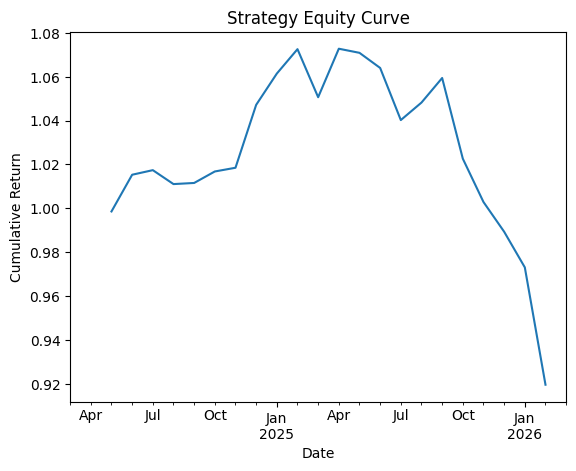

In [15]:
new_prices = yf.download(univ, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

monthly_prices = new_prices.resample('ME').last()
monthly_prices = monthly_prices.iloc[:-1]
returns = monthly_prices.pct_change().dropna()

signals.index = signals.index.normalize()
returns.index = returns.index.normalize()
returns = returns[signals.columns]
strat_returns = (signals * returns).mean(axis=1)

equity_curve = (1 + strat_returns).cumprod()

equity_curve.plot(title='Strategy Equity Curve')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

In [16]:
monthly_prices

Ticker,AAPL,ADBE,AMZN,AVGO,BAC,CAT,COIN,COST,CRM,DIS,...,ORCL,PEP,PG,PYPL,TER,TMUS,TXN,UPS,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2024-04-30,168.793823,462.829987,175.000000,127.424149,35.323376,326.317291,203.929993,716.193787,266.058655,108.897614,...,111.765221,163.690216,156.017120,67.558800,115.429985,159.167267,166.363922,131.290817,35.182240,58.169460
2024-05-31,190.774551,444.760010,176.440002,130.195511,38.167568,330.169891,225.919998,802.376648,231.928238,101.850136,...,115.145203,160.889328,157.298141,62.655022,139.982025,170.276886,185.219666,125.056107,36.661156,64.675064
2024-06-30,209.003571,555.539978,193.250000,157.838654,38.188457,324.883575,222.229996,842.104736,254.345490,97.321732,...,138.736267,154.683121,157.661407,57.721397,147.282043,171.464203,184.763779,123.183846,36.741341,66.592888
2024-07-31,220.375610,551.650024,186.979996,157.963516,38.706982,339.035583,224.360001,815.533691,256.425812,92.256409,...,137.403656,161.942215,154.608810,65.430176,130.268478,177.400909,194.838104,117.350929,36.690662,67.507545
2024-08-31,227.505539,574.409973,178.500000,160.067352,39.129482,348.730713,183.360001,885.360046,250.579926,88.997055,...,139.216675,162.139175,164.976334,72.044815,135.800613,194.031250,204.904572,117.185982,37.831585,76.172318
2024-09-30,231.479446,517.780029,186.330002,170.141464,38.350445,383.025970,178.169998,879.546265,271.624756,94.718155,...,167.899460,160.699448,166.572815,77.615036,133.145721,201.490967,197.476624,124.287338,40.665787,79.644119
2024-10-31,224.435699,478.079987,186.399994,167.448792,40.418743,369.738403,179.250000,867.303284,289.150238,94.727997,...,165.748901,156.947739,159.793716,78.878281,105.588036,217.894562,195.495392,122.208893,38.744026,80.827675
2024-11-30,236.040573,515.929993,207.889999,159.863937,45.918083,399.134644,296.200012,965.515808,327.476013,115.672539,...,182.537094,154.462357,173.414581,86.308556,109.477242,241.982941,193.445740,125.244858,40.776409,91.233200
2024-12-31,249.059464,444.679993,219.389999,229.282791,42.713657,356.529266,248.300003,910.270020,332.161499,110.132034,...,164.563873,144.922211,162.183151,84.896103,125.321587,216.299072,180.435806,116.367332,36.776028,89.310081


In [17]:
strat_returns

2024-03-31         NaN
2024-04-30         NaN
2024-05-31   -0.001435
2024-06-30    0.016762
2024-07-31    0.002059
2024-08-31   -0.006244
2024-09-30    0.000507
2024-10-31    0.005175
2024-11-30     0.00167
2024-12-31    0.028135
2025-01-31    0.013621
2025-02-28    0.010482
2025-03-31    -0.02042
2025-04-30    0.021038
2025-05-31   -0.001746
2025-06-30   -0.006434
2025-07-31   -0.022324
2025-08-31    0.007669
2025-09-30    0.010683
2025-10-31    -0.03472
2025-11-30    -0.01931
2025-12-31   -0.013503
2026-01-31   -0.016417
2026-02-28   -0.054962
2026-03-31         NaN
Freq: ME, dtype: object

### Performance Analysis

In [18]:
sharpe_ratio = strat_returns.mean() / strat_returns.std() * np.sqrt(12)
print(f'Sharpe Ratio: {sharpe_ratio:.2f}')

Sharpe Ratio: -0.65
